In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from tqdm import tqdm

In [3]:
df = pd.read_csv("arXiv_scientific_dataset.csv")
df = df.head(20000)

In [4]:
df.head()

,id,title,category,category_code,published_date,updated_date,authors,first_author,summary,summary_word_count
0,cs-9308101v1,Dynamic Backtracking,Artificial Intelligence,cs.AI,8/1/93,8/1/93,['M. L. Ginsberg'],'M. L. Ginsberg',Because of their occasional need to return to ...,79
1,cs-9308102v1,A Market-Oriented Programming Environment and ...,Artificial Intelligence,cs.AI,8/1/93,8/1/93,['M. P. Wellman'],'M. P. Wellman',Market price systems constitute a well-underst...,119
2,cs-9309101v1,An Empirical Analysis of Search in GSAT,Artificial Intelligence,cs.AI,9/1/93,9/1/93,"['I. P. Gent', 'T. Walsh']",'I. P. Gent',We describe an extensive study of search in GS...,167
3,cs-9311101v1,The Difficulties of Learning Logic Programs wi...,Artificial Intelligence,cs.AI,11/1/93,11/1/93,"['F. Bergadano', 'D. Gunetti', 'U. Trinchero']",'F. Bergadano',As real logic programmers normally use cut (!)...,174
4,cs-9311102v1,Software Agents: Completing Patterns and Const...,Artificial Intelligence,cs.AI,11/1/93,11/1/93,"['J. C. Schlimmer', 'L. A. Hermens']",'J. C. Schlimmer',To support the goal of allowing users to recor...,187


In [5]:
df.shape

(20000, 10)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   id                  20000 non-null  object
 1   title               20000 non-null  object
 2   category            20000 non-null  object
 3   category_code       20000 non-null  object
 4   published_date      20000 non-null  object
 5   updated_date        20000 non-null  object
 6   authors             20000 non-null  object
 7   first_author        20000 non-null  object
 8   summary             20000 non-null  object
 9   summary_word_count  20000 non-null  int64 
dtypes: int64(1), object(9)
memory usage: 1.5+ MB


In [7]:
df.isnull().sum()

id                    0
title                 0
category              0
category_code         0
published_date        0
updated_date          0
authors               0
first_author          0
summary               0
summary_word_count    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df = df.drop_duplicates()

df = df.dropna(subset=["title", "summary"])

df.reset_index(drop=True, inplace=True)

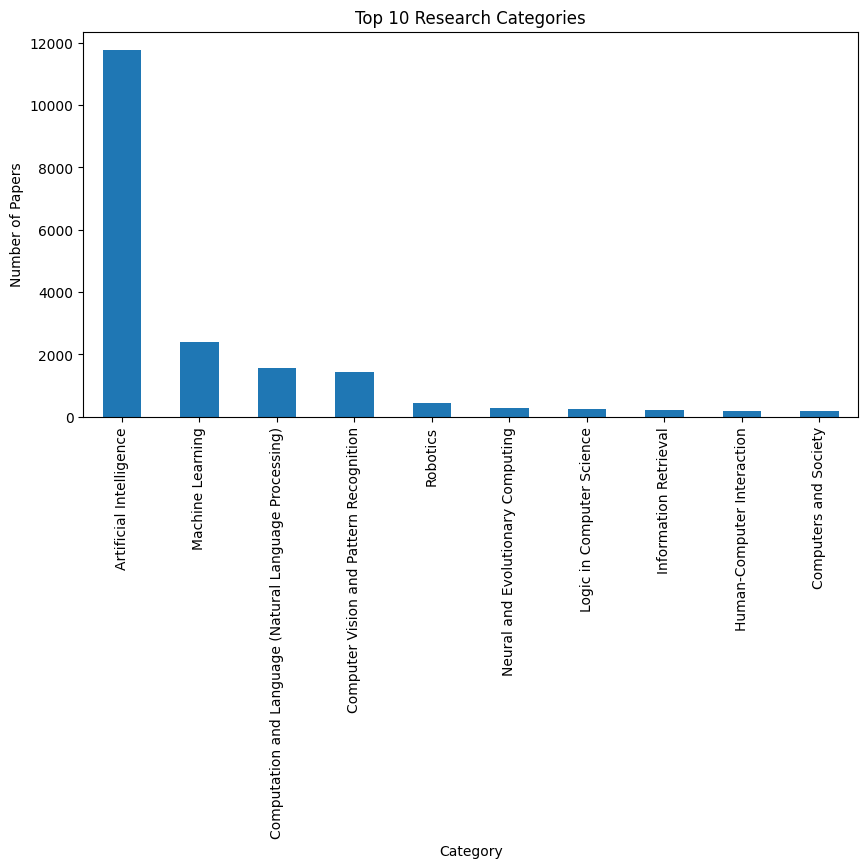

In [10]:
plt.figure(figsize=(10,5))

df["category"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Research Categories")
plt.xlabel("Category")
plt.ylabel("Number of Papers")

plt.xticks

plt.show()

In [11]:
import re
import string

from sentence_transformers import SentenceTransformer
from tqdm.auto import tqdm

In [12]:
def preprocess(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"\d+", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [13]:
df["processed_text"] = (
    df["title"] + " " + df["summary"]
).apply(preprocess)

df[["title", "processed_text"]].head()

,title,processed_text
0,Dynamic Backtracking,dynamic backtracking because of their occasion...
1,A Market-Oriented Programming Environment and ...,a marketoriented programming environment and i...
2,An Empirical Analysis of Search in GSAT,an empirical analysis of search in gsat we des...
3,The Difficulties of Learning Logic Programs wi...,the difficulties of learning logic programs wi...
4,Software Agents: Completing Patterns and Const...,software agents completing patterns and constr...


In [14]:
model = SentenceTransformer("all-MiniLM-L6-v2")

C:\Users\mayan\AppData\Local\Programs\Python\Python312\Lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [15]:
texts = df["processed_text"].tolist()

In [16]:
embeddings = model.encode(
    texts,
    batch_size=128,
    show_progress_bar=True,
    convert_to_numpy=True  
)

Batches:   0%|          | 0/157 [00:00<?, ?it/s]

In [17]:
embeddings.shape

(20000, 384)

In [18]:
np.save("embeddings.npy", embeddings)
embeddings = np.load("embeddings.npy")

In [19]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [20]:
pca = PCA(n_components=2)

pca_embeddings = pca.fit_transform(embeddings)

In [21]:
pca_embeddings.shape

(20000, 2)

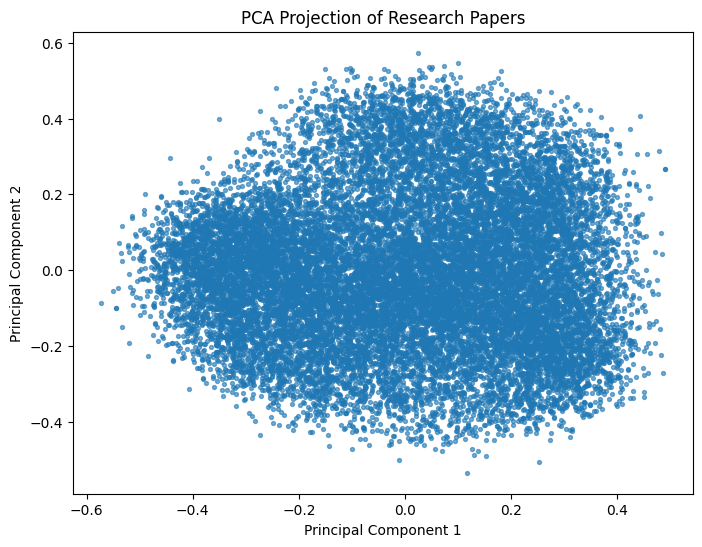

In [22]:
plt.figure(figsize=(8,6))

plt.scatter(
    pca_embeddings[:,0],
    pca_embeddings[:,1],
    s=8,
    alpha=0.6
)

plt.title("PCA Projection of Research Papers")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.show()

In [23]:
kmeans = KMeans(
    n_clusters=10,
    random_state=42
)

clusters = kmeans.fit_predict(embeddings)

In [24]:
df["Cluster"] = clusters

df[["title","category","Cluster"]].head()

,title,category,Cluster
0,Dynamic Backtracking,Artificial Intelligence,7
1,A Market-Oriented Programming Environment and ...,Artificial Intelligence,7
2,An Empirical Analysis of Search in GSAT,Artificial Intelligence,7
3,The Difficulties of Learning Logic Programs wi...,Artificial Intelligence,6
4,Software Agents: Completing Patterns and Const...,Artificial Intelligence,8


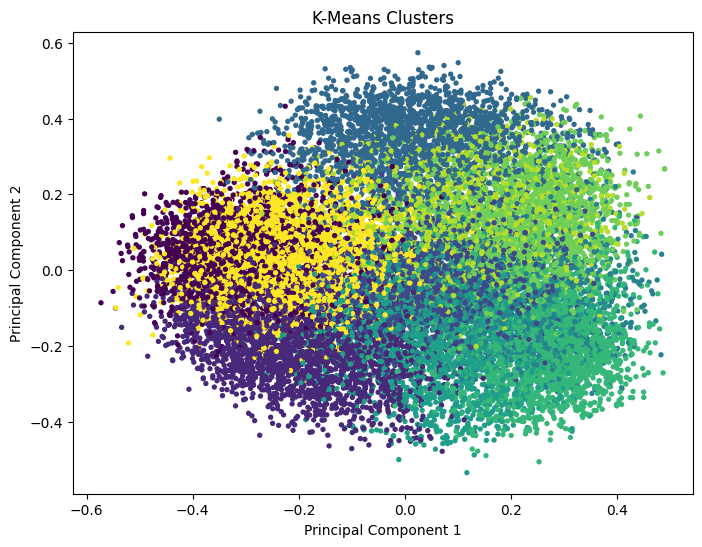

In [25]:
plt.figure(figsize=(8,6))

plt.scatter(
    pca_embeddings[:,0],
    pca_embeddings[:,1],
    c=clusters,
    s=8
)

plt.title("K-Means Clusters")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.show()

In [26]:
df["Cluster"].value_counts().sort_index()

Cluster
0    1695
1    2615
2    1583
3    2176
4    1715
5    2137
6    1869
7    1954
8    1578
9    2678
Name: count, dtype: int64

In [27]:
import faiss

In [28]:
dimension = embeddings.shape[1]

index = faiss.IndexFlatL2(dimension)

index.add(embeddings)

In [29]:
def search_papers(query, top_k=5):

    query_embedding = model.encode([preprocess(query)])

    distances, indices = index.search(query_embedding, top_k)

    return df.iloc[indices[0]][["title", "category", "authors"]]

In [30]:
search_papers("Deep Learning for Medical Image Analysis")

,title,category,authors
7317,"Case Studies on X-Ray Imaging, MRI and Nuclear...",Artificial Intelligence,"['Shuvra Sarker', 'Angona Biswas', 'MD Abdulla..."
15908,Machine Learning and Deep Learning Methods for...,Machine Learning,"['G Jignesh Chowdary', 'Suganya G', 'Premalath..."
11846,An Interpretable Deep Hierarchical Semantic Co...,Computer Vision and Pattern Recognition,"['Shiwen Shen', 'Simon X. Han', 'Denise R. Abe..."
7358,AutoML Systems For Medical Imaging,Artificial Intelligence,"['Tasmia Tahmida Jidney', 'Angona Biswas', 'MD..."
14146,Swin MAE: Masked Autoencoders for Small Datasets,Computer Vision and Pattern Recognition,"[""Zi'an Xu"", 'Yin Dai', 'Fayu Liu', 'Weibing C..."


In [31]:
search_papers("Cyber Security using Artificial Intelligence")

,title,category,authors
12103,Use of Artificial Intelligence Techniques / Ap...,Artificial Intelligence,['Ensar Şeker']
17381,"XAI for Cybersecurity: State of the Art, Chall...",Cryptography and Security,"['Gautam Srivastava', 'Rutvij H Jhaveri', 'Swe..."
19614,Automated Cyber Defence: A Review,Cryptography and Security,"['Sanyam Vyas', 'John Hannay', 'Andrew Bolton'..."
1007,Classification of artificial intelligence ids ...,Artificial Intelligence,"['N. Ugtakhbayar', 'D. Battulga', 'Sh. Sodbileg']"
16026,Proceedings of the 1st International Workshop ...,Cryptography and Security,"['Damian Marriott', 'Kimberly Ferguson-Walter'..."


In [32]:
def recommend_papers(paper_index, top_k=5):

    distances, indices = index.search(
        embeddings[paper_index].reshape(1,-1),
        top_k + 1
    )

    recommendations = df.iloc[
        indices[0][1:]
    ][["title","category","authors"]]

    return recommendations

In [33]:
faiss.write_index(index, "faiss_index.index")

In [34]:
import spacy

nlp = spacy.load("en_core_web_sm")

In [35]:
sample_text = df.loc[7, "summary"]

doc = nlp(sample_text)

print(sample_text)

Learning the past tense of English verbs - a seemingly minor aspect of
language acquisition - has generated heated debates since 1986, and has become
a landmark task for testing the adequacy of cognitive modeling. Several
artificial neural networks (ANNs) have been implemented, and a challenge for
better symbolic models has been posed. In this paper, we present a
general-purpose Symbolic Pattern Associator (SPA) based upon the decision-tree
learning algorithm ID3. We conduct extensive head-to-head comparisons on the
generalization ability between ANN models and the SPA under different
representations. We conclude that the SPA generalizes the past tense of unseen
verbs better than ANN models by a wide margin, and we offer insights as to why
this should be the case. We also discuss a new default strategy for
decision-tree learning algorithms.


In [36]:
entities = []

for ent in doc.ents:
    entities.append([ent.text, ent.label_])

entity_df = pd.DataFrame(
    entities,
    columns=["Entity", "Type"]
)

entity_df

,Entity,Type
0,English,LANGUAGE
1,1986,DATE
2,Symbolic Pattern Associator,ORG
3,SPA,ORG
4,ID3,GPE
5,ANN,ORG
6,SPA,ORG
7,SPA,ORG
8,ANN,ORG


In [37]:
entity_df["Type"].value_counts()

Type
ORG         6
LANGUAGE    1
DATE        1
GPE         1
Name: count, dtype: int64

In [38]:
def extract_entities(text):

    doc = nlp(text)

    return [
        (ent.text, ent.label_)
        for ent in doc.ents
    ]

In [39]:
df.loc[:99, "Entities"] = df.loc[:99, "summary"].apply(extract_entities)

In [40]:
df[["title", "Entities"]].head()

,title,Entities
0,Dynamic Backtracking,[]
1,A Market-Oriented Programming Environment and ...,"[(WALRAS, ORG)]"
2,An Empirical Analysis of Search in GSAT,"[(GSAT, ORG), (two, CARDINAL)]"
3,The Difficulties of Learning Logic Programs wi...,"[(first, ORDINAL)]"
4,Software Agents: Completing Patterns and Const...,"[(two, CARDINAL), (First, ORDINAL), (Second, O..."


In [41]:
from keybert import KeyBERT

In [42]:
kw_model = KeyBERT(model)

In [43]:
sample_text = df.loc[7, "summary"]

keywords = kw_model.extract_keywords(
    sample_text,
    keyphrase_ngram_range=(1,2),
    stop_words="english",
    top_n=10
)

keywords

[('symbolic models', 0.4565),
 ('tree learning', 0.4288),
 ('verbs better', 0.4112),
 ('symbolic pattern', 0.4071),
 ('learning past', 0.4033),
 ('better symbolic', 0.3981),
 ('verbs', 0.3969),
 ('english verbs', 0.3936),
 ('unseen verbs', 0.3879),
 ('tense english', 0.3848)]

In [44]:
keyword_df = pd.DataFrame(
    keywords,
    columns=["Keyword","Score"]
)

keyword_df

,Keyword,Score
0,symbolic models,0.4565
1,tree learning,0.4288
2,verbs better,0.4112
3,symbolic pattern,0.4071
4,learning past,0.4033
5,better symbolic,0.3981
6,verbs,0.3969
7,english verbs,0.3936
8,unseen verbs,0.3879
9,tense english,0.3848


In [45]:
def extract_keywords(text):
    return kw_model.extract_keywords(
        text,
        keyphrase_ngram_range=(1,2),
        stop_words="english",
        top_n=5
    )

In [46]:
keyword_df = df.head(100).copy()

keyword_df["Keywords"] = keyword_df["summary"].apply(extract_keywords)

In [47]:
keyword_df.loc[7, ["title", "Keywords"]]

title       Learning the Past Tense of English Verbs: The ...
Keywords    [(symbolic models, 0.4565), (tree learning, 0....
Name: 7, dtype: object

In [48]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [49]:
label_encoder = LabelEncoder()

y = label_encoder.fit_transform(df["category"])

In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    embeddings,
    y,
    test_size=0.2,
    random_state=42
)

In [51]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [52]:
clf = SGDClassifier(
    loss="log_loss",
    max_iter=300,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

clf.fit(X_train_scaled, y_train)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 32 concurrent workers.


-- Epoch 1
-- Epoch 1
-- Epoch 1
-- Epoch 1
-- Epoch 1
-- Epoch 1
-- Epoch 1
-- Epoch 1
-- Epoch 1
-- Epoch 1
-- Epoch 1
-- Epoch 1
-- Epoch 1
Norm: 55.29, NNZs: 384, Bias: -1181.889094, T: 16000, Avg. loss: 5.608957, Objective: 8.242776
Total training time: 0.04 seconds.
-- Epoch 2
-- Epoch 1
-- Epoch 1
-- Epoch 1
Norm: 56.35, NNZs: 384, Bias: -1240.067910, T: 16000, Avg. loss: 5.958585, Objective: 8.683055
Total training time: 0.03 seconds.
-- Epoch 2
Norm: 64.81, NNZs: 384, Bias: -1177.457397, T: 16000, Avg. loss: 6.028112, Objective: 8.779281
Total training time: 0.03 seconds.
-- Epoch 2
-- Epoch 1
-- Epoch 1
-- Epoch 1
Norm: 53.82, NNZs: 384, Bias: -1198.568701, T: 16000, Avg. loss: 5.527247, Objective: 8.120109
Total training time: 0.04 seconds.
-- Epoch 2
-- Epoch 1
Norm: 93.78, NNZs: 384, Bias: -1190.989176, T: 16000, Avg. loss: 6.270219, Objective: 8.987637
Total training time: 0.03 seconds.
-- Epoch 2
-- Epoch 1
Norm: 60.51, NNZs: 384, Bias: -1269.835921, T: 16000, Avg. loss:

[Parallel(n_jobs=-1)]: Done  84 out of  84 | elapsed:   14.8s finished
C:\Users\mayan\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


,"loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'log_loss'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",300
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",1
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",-1


In [53]:
y_pred = clf.predict(X_test_scaled)

accuracy_score(y_test, y_pred)

0.71875

In [54]:
print(classification_report(
    y_test,
    y_pred,
    labels=range(len(label_encoder.classes_)),
    target_names=label_encoder.classes_,
    zero_division=0
))

                                                        precision    recall  f1-score   support

                Adaptation and Self-Organizing Systems       0.00      0.00      0.00         3
                                    Algebraic Topology       0.00      0.00      0.00         0
                             Applications (Statistics)       0.00      0.00      0.00         1
                               Artificial Intelligence       0.76      0.85      0.80      2359
                              Astrophysics of Galaxies       0.00      0.00      0.00         0
                       Atmospheric and Oceanic Physics       0.00      0.00      0.00         0
                           Audio and Speech Processing       0.00      0.00      0.00         1
                   Cellular Automata and Lattice Gases       0.00      0.00      0.00         1
                                         Combinatorics       0.00      0.00      0.00         1
                              Computati

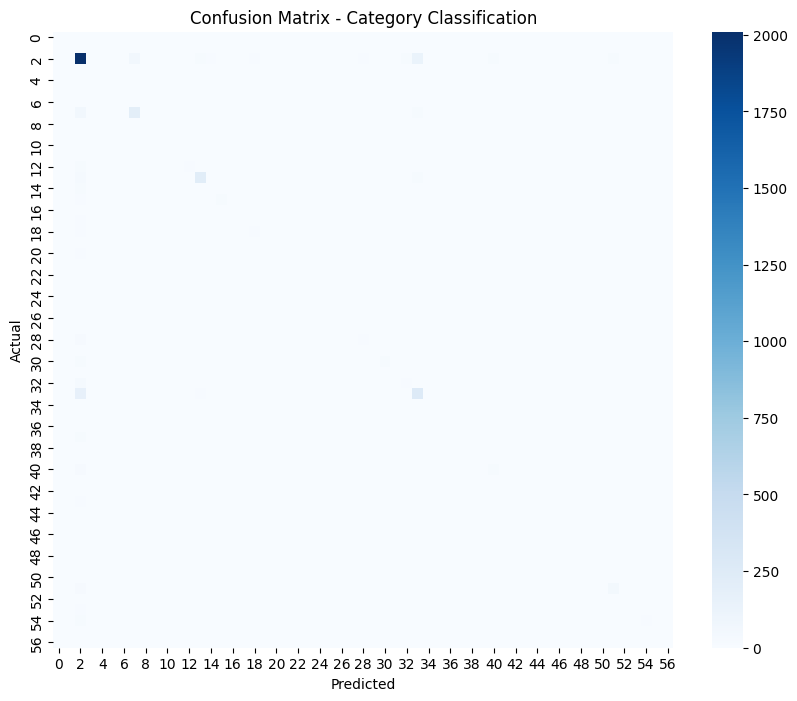

In [55]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))

sns.heatmap(cm, cmap="Blues")

plt.title("Confusion Matrix - Category Classification")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [56]:
from transformers import pipeline

In [57]:
summarizer = pipeline(
    "summarization",
    model="facebook/bart-large-cnn",
    framework="pt",
    device=0
)

In [58]:
sample_text = df.loc[7, "summary"]

summary = summarizer(
    sample_text,
    max_length=60,
    min_length=20,
    do_sample=False
)

summary[0]["summary_text"]

'Learning the past tense of English verbs has generated heated debates since 1986. Several artificial neural networks (ANNs) have been implemented. We present ageneral-purpose Symbolic Pattern Associator (SPA) based upon the decision-tree learning algorithm ID3.'

In [59]:
def summarize_texts_batch(text_list):
    summaries = summarizer(
        text_list,
        max_length=60,
        min_length=20,
        num_beams=1,
        do_sample=False,
        batch_size=4
    )
    return [s["summary_text"] for s in summaries]

In [60]:
summary_df = df.head(20).copy()

summary_df["Generated_Summary"] = summarize_texts_batch(summary_df["summary"].tolist())

C:\Users\mayan\AppData\Local\Programs\Python\Python312\Lib\site-packages\transformers\generation\configuration_utils.py:615: UserWarning: `num_beams` is set to 1. However, `early_stopping` is set to `True` -- this flag is only used in beam-based generation modes. You should set `num_beams>1` or unset `early_stopping`.
  warnings.warn(
C:\Users\mayan\AppData\Local\Programs\Python\Python312\Lib\site-packages\transformers\generation\configuration_utils.py:634: UserWarning: `num_beams` is set to 1. However, `length_penalty` is set to `2.0` -- this flag is only used in beam-based generation modes. You should set `num_beams>1` or unset `length_penalty`.
  warnings.warn(


In [61]:
summary_df[["title", "summary", "Generated_Summary"]]

,title,summary,Generated_Summary
0,Dynamic Backtracking,Because of their occasional need to return to ...,. Backtracking methods can sometimes erase mea...
1,A Market-Oriented Programming Environment and ...,Market price systems constitute a well-underst...,Market price systems constitute a well-underst...
2,An Empirical Analysis of Search in GSAT,We describe an extensive study of search in GS...,The study provides a more complete picture of ...
3,The Difficulties of Learning Logic Programs wi...,As real logic programmers normally use cut (!)...,Cut is a procedural predicate in logic program...
4,Software Agents: Completing Patterns and Const...,To support the goal of allowing users to recor...,Paper describes an interactive note-taking sys...
5,Decidable Reasoning in Terminological Knowledg...,Terminological knowledge representation system...,Terminological knowledge representation system...
6,Teleo-Reactive Programs for Agent Control,A formalism is presented for computing and org...,Teleo-reactive (T-R) programs are computer pro...
7,Learning the Past Tense of English Verbs: The ...,Learning the past tense of English verbs - a s...,The past tense of English verbs has generated ...
8,Substructure Discovery Using Minimum Descripti...,The ability to identify interesting and repeti...,SUBDUE is a program that discovers substructur...
9,Bias-Driven Revision of Logical Domain Theories,The theory revision problem is the problem of ...,Theory revision problem is the problem of how ...


In [62]:
qa_pipeline = pipeline(
    "question-answering",
    model="distilbert-base-cased-distilled-squad"
)

model.safetensors:   0%|          | 0.00/261M [00:00<?, ?B/s]

C:\Users\mayan\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\mayan\.cache\huggingface\hub\models--distilbert-base-cased-distilled-squad. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Hardware accelerator e.g. GPU is available in the environment, but no `device` argument is passed to the `Pipeline` object. Model will be on CPU.


In [71]:
paper = df.loc[7, "summary"]

questions = [
    "What is the objective of this research?",
    "What challenge is addressed in this paper?",
    "What approach is introduced?",
    "What are the key findings?",
    "What technique is used in this study?"
]

for q in questions:
    print(f"Question: {q}")
    print("Answer:", answer_question(q, paper))

Question: What is the objective of this research?
Answer: testing the adequacy of cognitive modeling
Question: What challenge is addressed in this paper?
Answer: better symbolic models
Question: What approach is introduced?
Answer: SPA
Question: What are the key findings?
Answer: we offer insights as to why
this should be the case
Question: What technique is used in this study?
Answer: Symbolic Pattern Associator


In [72]:
def answer_question(question, context):
    result = qa_pipeline(
        question=question,
        context=context
    )
    return result["answer"]

In [73]:
answer_question(
    "What method is used in this research?",
    df.loc[7, "summary"]
)

'decision-tree\nlearning algorithm ID3'

In [74]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

In [75]:
print("Total Papers:", len(df))
print("Categories:", df["category"].nunique())
print("Clusters:", df["Cluster"].nunique())
print("Embedding Dimension:", embeddings.shape[1])
print("FAISS Index Size:", index.ntotal)
print("Classification Accuracy:", round(accuracy * 100, 2), "%")

Total Papers: 20000
Categories: 88
Clusters: 10
Embedding Dimension: 384
FAISS Index Size: 20000
Classification Accuracy: 71.88 %
